2026-03-09 21:43:14.527216: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Original training set shape: (38840, 4), (38840,)
SMOTE training set shape: (58260, 4), (58260,)
Class distribution after SMOTE: [29130 29130]
[29130 29405]
Use /var/folders/wn/xdcqjsfn1q37gf381p3xc6500000gn/T/tmpzos9769a as temporary training directory
Reading training dataset...
Training dataset read in 0:00:06.703561. Found 38840 examples.
Training model...


[INFO 26-03-09 21:43:45.4842 PDT kernel.cc:1233] Loading model from path /var/folders/wn/xdcqjsfn1q37gf381p3xc6500000gn/T/tmpzos9769a/model/ with prefix ba1f7795447c432c
[INFO 26-03-09 21:43:48.3385 PDT decision_forest.cc:734] Model loaded with 300 root(s), 873944 node(s), and 4 input feature(s).
[INFO 26-03-09 21:43:48.3388 PDT abstract_model.cc:1344] Engine "RandomForestOptPred" built
[INFO 26-03-09 21:43:48.3389 PDT kernel.cc:1061] Use fast generic engine


Model trained in 0:00:15.630559
Compiling model...
Model compiled.
VALIDATION RESULTS
2738/2738 [==============================] - 169s 62ms/step
-------------------------
Classification Report
-------------------------
              precision    recall  f1-score   support

           0       1.00      0.86      0.92   2735348
           1       0.00      0.58      0.01      2081

    accuracy                           0.86   2737429
   macro avg       0.50      0.72      0.46   2737429
weighted avg       1.00      0.86      0.92   2737429



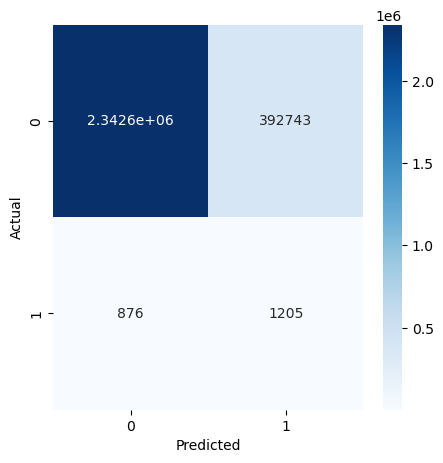

TEST RESULTS
2738/2738 [==============================] - 181s 66ms/step
-------------------------
Classification Report
-------------------------
              precision    recall  f1-score   support

           0       1.00      0.86      0.92   2735349
           1       0.00      0.58      0.01      2080

    accuracy                           0.86   2737429
   macro avg       0.50      0.72      0.46   2737429
weighted avg       1.00      0.86      0.92   2737429



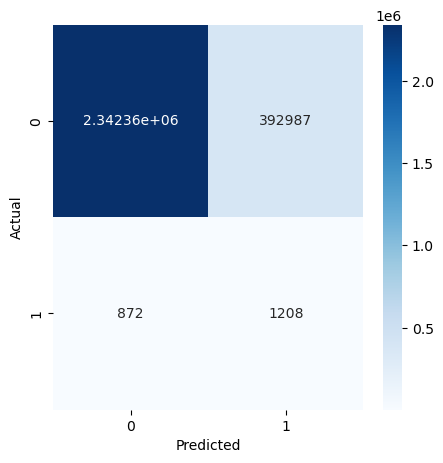

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_decision_forests as tfdf
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------
# Load Data
# -----------------------------

MODIS_FIRMS_TRAIN_VAL_TEST_DATASET = '../data/processed/modis_firms_train_val_test_dataset.npz'

data = np.load(MODIS_FIRMS_TRAIN_VAL_TEST_DATASET)

X_train = data["X_train"]
y_train = data["y_train"]
X_train_balanced = data["X_train_balanced"]
y_train_balanced = data["y_train_balanced"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

# -----------------------------
# SMOTE
# -----------------------------

from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the balanced training data
X_train_smote, y_train_smote = smote.fit_resample(X_train_balanced, y_train_balanced)

print(f"Original training set shape: {X_train_balanced.shape}, {y_train_balanced.shape}")
print(f"SMOTE training set shape: {X_train_smote.shape}, {y_train_smote.shape}")
print(f"Class distribution after SMOTE: {np.bincount(y_train_smote)}")

# -----------------------------
# ADASYN
# -----------------------------

from imblearn.over_sampling import ADASYN
adasyn = ADASYN(sampling_strategy='minority')
X_res, y_res = adasyn.fit_resample(X_train_balanced, y_train_balanced)
print(np.bincount(y_res))

# -----------------------------
# Random Forest 
# -----------------------------

feature_names = ["NDVI", "EVI", "LST_Day", "LST_Night"]

train_df = pd.DataFrame(X_train_balanced, columns=feature_names)
train_df["label"] = y_train_balanced

val_df = pd.DataFrame(X_val, columns=feature_names)
val_df["label"] = y_val

test_df = pd.DataFrame(X_test, columns=feature_names)
test_df["label"] = y_test

# Convert Pandas DataFrames to TensorFlow datasets
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(train_df, label="label")
val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(val_df, label="label")
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(test_df, label="label")

# Train a Random Forest model.
model = tfdf.keras.RandomForestModel()
model.fit(train_ds)

def evaluate_model(model, dataset, y_true, threshold=0.3):
    # TF-DF predicts probabilities for class 1 by default with GBT
    y_prob = model.predict(dataset).reshape(-1)
    y_pred = (y_prob >= threshold).astype(int)

    cnf_matrix = confusion_matrix(y_true, y_pred)
    print("-"*25)
    print("Classification Report")
    print("-"*25)
    print(classification_report(y_true, y_pred))

    plt.figure(figsize=(5,5))
    sns.heatmap(cnf_matrix, annot=True, fmt="g", cmap=plt.cm.Blues)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return y_pred

# Evaluate on Validation and Test sets

print("VALIDATION RESULTS")
y_val_pred = evaluate_model(model, val_ds, y_val, threshold=0.3)  # low threshold to catch more fires

print("TEST RESULTS")
y_test_pred = evaluate_model(model, test_ds, y_test, threshold=0.3)